## Article Recommendation using Bag-of-Words and TF-IDF

This notebook demonstrates how to build a simple article recommendation system using two popular NLP techniques: Bag-of-Words (BoW) and TF-IDF. We will use cosine similarity to find articles similar to a given article.

### 1. Import Necessary Libraries

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

nltk.download('stopwords')
nltk.download('wordnet')
print("Libraries imported and NLTK data downloaded.")

### 2. Prepare Sample Data

For demonstration, we'll create a small dataset of article texts. In a real-world scenario, you would load your articles from a CSV, database, or API.

In [ ]:
data = {
    'article_id': [1, 2, 3, 4, 5],
    'title': [
        'Introduction to Machine Learning',
        'Deep Learning for Image Recognition',
        'Natural Language Processing Basics',
        'Machine Learning Algorithms',
        'Computer Vision with Neural Networks'
    ],
    'text': [
        'Machine learning is a field of artificial intelligence that uses statistical techniques to give computer systems the ability to learn from data. It is a very important field.',
        'Deep learning is a subset of machine learning that uses neural networks with many layers to learn from vast amounts of data, especially for tasks like image recognition and natural language processing.',
        'Natural Language Processing (NLP) is a field of artificial intelligence that focuses on the interaction between computers and human language. It is important for text analysis.',
        'Various machine learning algorithms exist, such as linear regression, decision trees, and support vector machines. Choosing the right algorithm is crucial for predictive modeling.',
        'Computer vision is a field that deals with how computers can gain high-level understanding from digital images or videos. Neural networks, particularly convolutional neural networks, have revolutionized this area.'
    ]
}
df = pd.DataFrame(data)
display(df)

### 3. Text Preprocessing

Preprocessing is crucial for cleaning the text data before converting it into numerical features. This usually involves:
- Lowercasing
- Removing punctuation and special characters
- Tokenization (breaking text into words)
- Removing stop words (common words like 'the', 'is', 'a')
- Lemmatization (reducing words to their base form)

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower() # Lowercase
    text = re.sub(r'[^a-z\s]', '', text) # Remove punctuation and numbers
    tokens = text.split() # Tokenize
    tokens = [word for word in tokens if word not in stop_words] # Remove stopwords
    tokens = [lemmatizer.lemmatize(word) for word in tokens] # Lemmatize
    return ' '.join(tokens)

df['processed_text'] = df['text'].apply(preprocess_text)
display(df[['article_id', 'title', 'processed_text']])

### 4. Bag-of-Words (BoW) Representation

Bag-of-Words represents text as a collection of word counts, disregarding word order. `CountVectorizer` from scikit-learn is used for this.

In [ ]:
vectorizer_bow = CountVectorizer()
bow_matrix = vectorizer_bow.fit_transform(df['processed_text'])

bow_df = pd.DataFrame(bow_matrix.toarray(), columns=vectorizer_bow.get_feature_names_out())
print("Bag-of-Words Matrix:")
display(bow_df.head())

### 5. TF-IDF Representation

TF-IDF (Term Frequency-Inverse Document Frequency) weighs word counts by their importance, down-weighting words that appear frequently across many documents. `TfidfVectorizer` from scikit-learn is used for this.

In [ ]:
vectorizer_tfidf = TfidfVectorizer()
tfidf_matrix = vectorizer_tfidf.fit_transform(df['processed_text'])

tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer_tfidf.get_feature_names_out())
print("TF-IDF Matrix:")
display(tfidf_df.head())

### 6. Calculate Cosine Similarity for Recommendations

Cosine similarity measures the cosine of the angle between two non-zero vectors. A value close to 1 indicates high similarity, while a value close to 0 indicates low similarity.

We will calculate similarity matrices for both BoW and TF-IDF.

In [ ]:
bow_similarity_matrix = cosine_similarity(bow_matrix)
tfidf_similarity_matrix = cosine_similarity(tfidf_matrix)

print("BoW Similarity Matrix:")
display(pd.DataFrame(bow_similarity_matrix, index=df['title'], columns=df['title']))

print("\nTF-IDF Similarity Matrix:")
display(pd.DataFrame(tfidf_similarity_matrix, index=df['title'], columns=df['title']))

### 7. Get Recommendations

Now we can define a function to get the top N recommended articles for a given article based on a similarity matrix.

In [ ]:
def get_recommendations(article_title, similarity_matrix, df, top_n=3):
    # Get the index of the article that matches the title
    idx = df[df['title'] == article_title].index[0]

    # Get the similarity scores for this article with all other articles
    sim_scores = list(enumerate(similarity_matrix[idx]))

    # Sort the articles based on the similarity scores
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Get the scores of the top N most similar articles (excluding itself)
    sim_scores = sim_scores[1:top_n+1]

    # Get the article indices
    article_indices = [i[0] for i in sim_scores]

    # Return the top N most similar articles
    return df['title'].iloc[article_indices]

# Example Usage: Get recommendations for 'Machine Learning Algorithms' using TF-IDF
print(f"Recommendations for 'Machine Learning Algorithms' (TF-IDF):")
display(get_recommendations('Machine Learning Algorithms', tfidf_similarity_matrix, df))

print(f"\nRecommendations for 'Introduction to Machine Learning' (BoW):")
display(get_recommendations('Introduction to Machine Learning', bow_similarity_matrix, df))

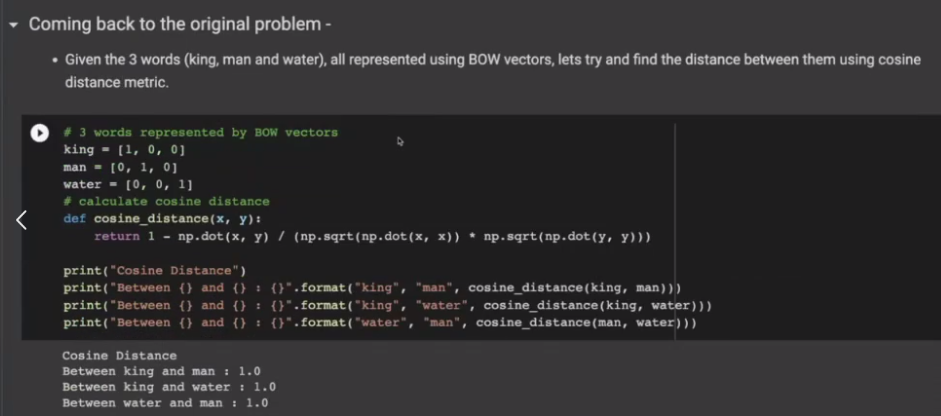

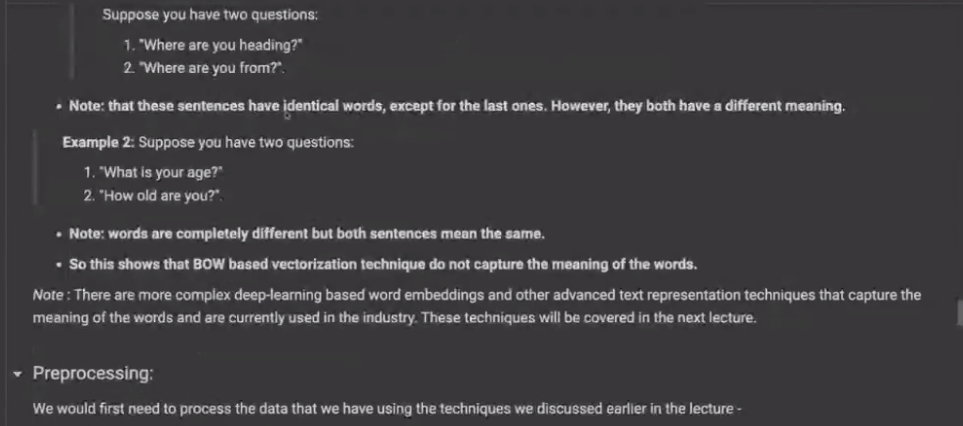

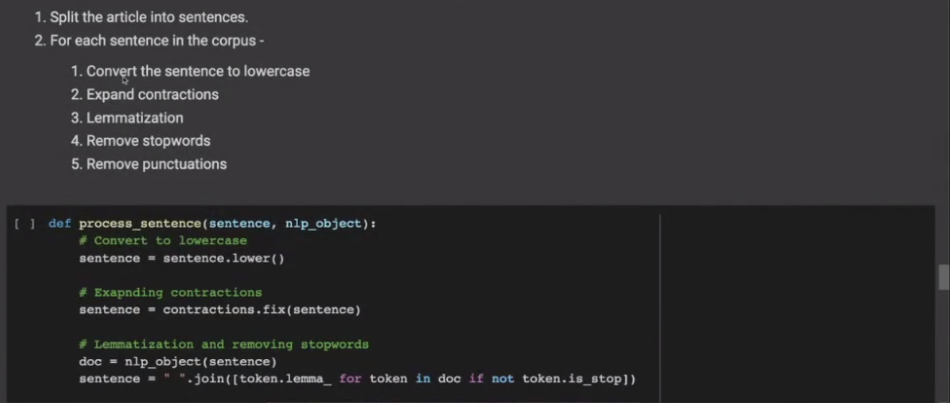

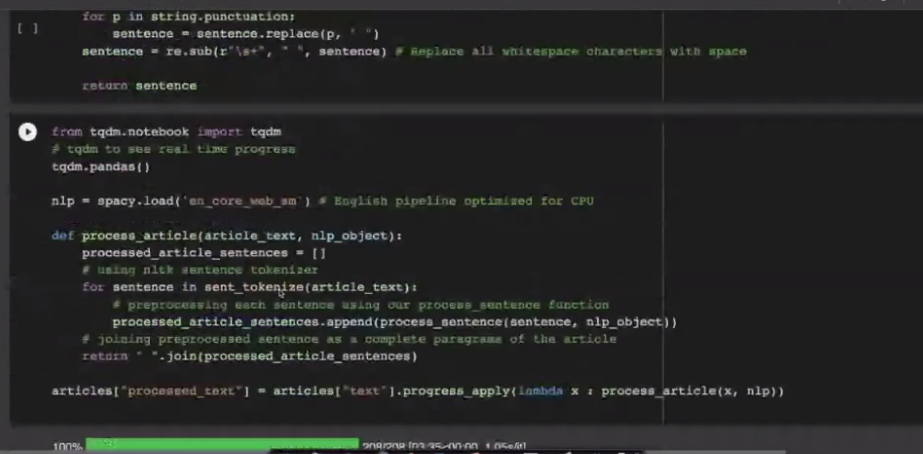

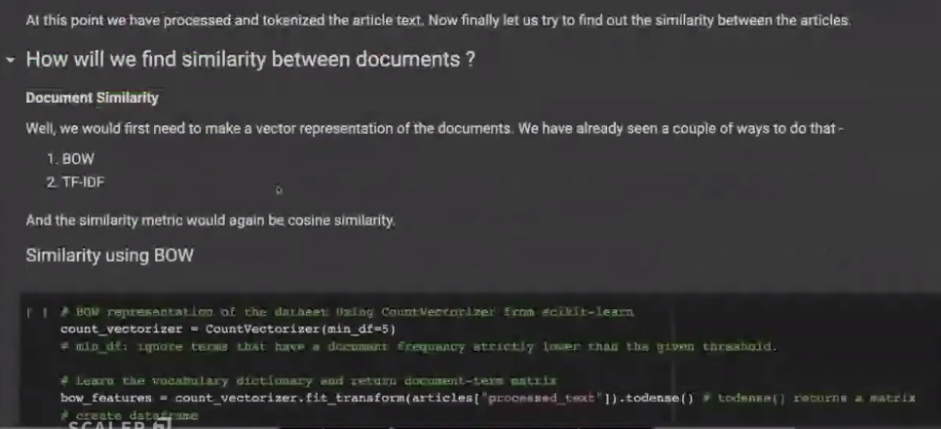

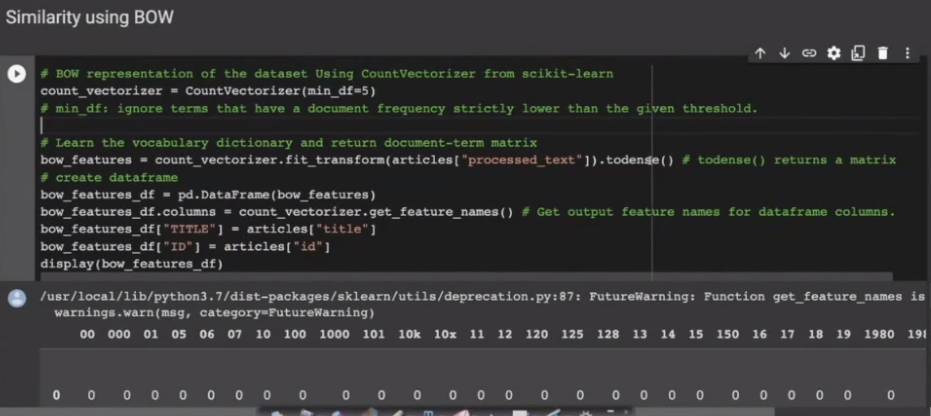

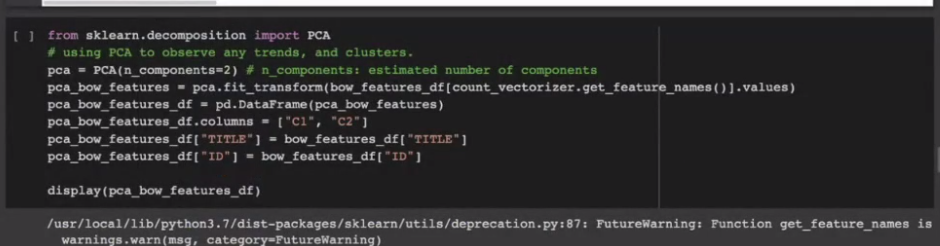

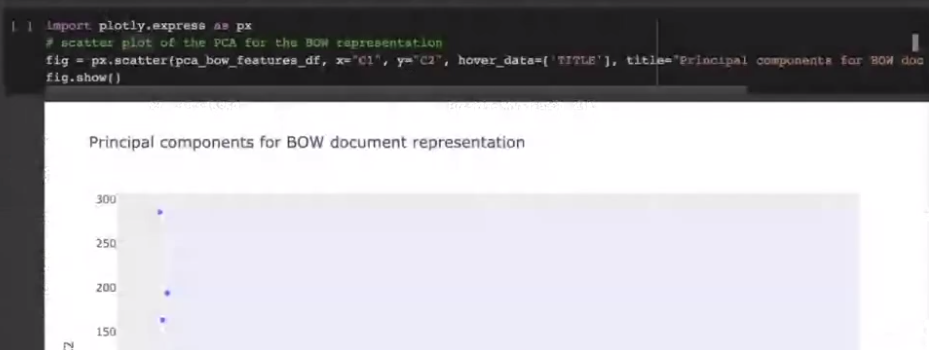

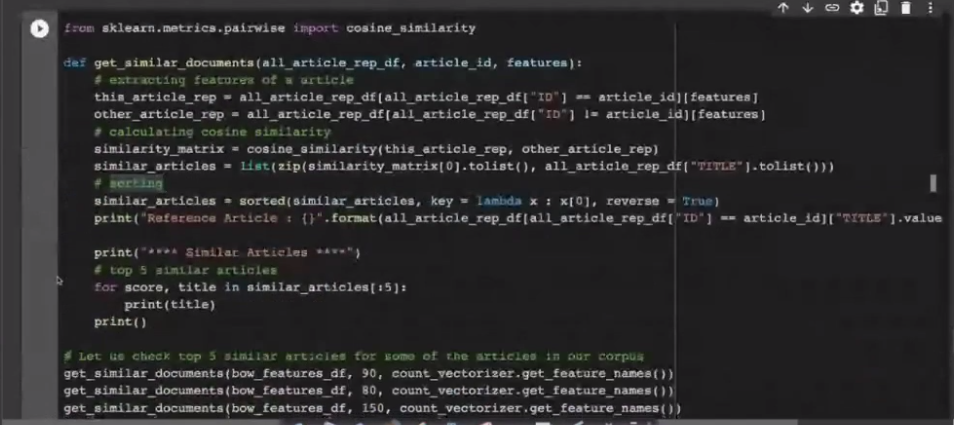

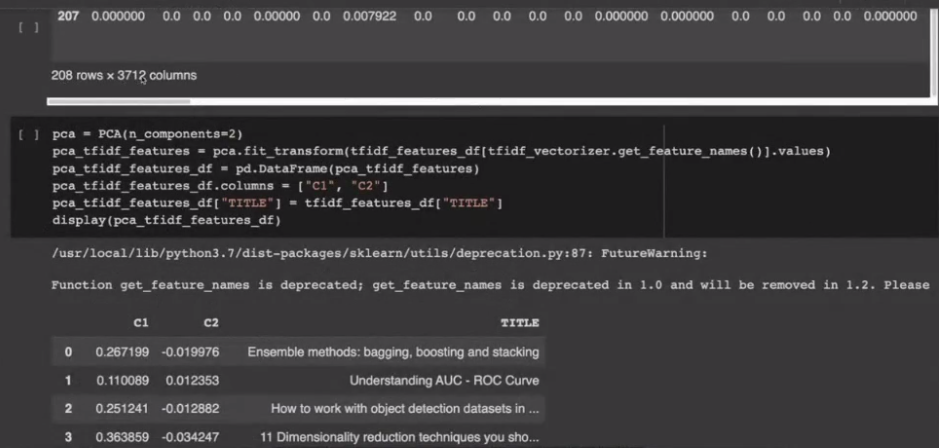